In [1]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import cv2

In [2]:
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical, image_dataset_from_directory
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('accuracy') > 0.96):
      print("\nAkurasi telah mencapai >96%. Stop training!")
      self.model.stop_training = True
callbacks = myCallback()

## Data Preparation

### Data Loading

In [5]:
# Download dataset dari kaggle
path = kagglehub.dataset_download("chandrashekarnatesh/poultry-diseases")

print("Path to dataset files:", path)

100%|██████████| 12.6G/12.6G [02:08<00:00, 105MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/chandrashekarnatesh/poultry-diseases/versions/3


In [6]:
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Streaming output truncated to the last 5000 lines.
/root/.cache/kagglehub/datasets/chandrashekarnatesh/poultry-diseases/versions/3/data/data/val/Healthy/healthy.94.jpg_aug45.JPG
/root/.cache/kagglehub/datasets/chandrashekarnatesh/poultry-diseases/versions/3/data/data/val/Healthy/healthy.1694.jpg_aug20.JPG
/root/.cache/kagglehub/datasets/chandrashekarnatesh/poultry-diseases/versions/3/data/data/val/Healthy/pcrhealthy.74.jpg_aug39.JPG
/root/.cache/kagglehub/datasets/chandrashekarnatesh/poultry-diseases/versions/3/data/data/val/Healthy/healthy.1291.jpg_aug10.JPG
/root/.cache/kagglehub/datasets/chandrashekarnatesh/poultry-diseases/versions/3/data/data/val/Healthy/healthy.1113.jpg_aug9.JPG
/root/.cache/kagglehub/datasets/chandrashekarnatesh/poultry-diseases/versions/3/data/data/val/Healthy/pcrhealthy.305.jpg_aug35.JPG
/root/.cache/kagglehub/datasets/chandrashekarnatesh/poultry-diseases/versions/3/data/data/val/Healthy/healthy.1818.jpg_aug23.JPG
/root/.cache/kagglehub/datasets/chandrashekarn

In [11]:
# Tentukan folder utama tempat gambar-gambar berada, misalnya folder 'train'
image_data = os.path.join(path)

# Ambil semua file dalam subfolder-subfolder (misalnya: train/A/*.jpg, train/B/*.jpg, dst.)
files = [i for i in glob.glob(image_data + "/*/*/*/*/")]

# Acak urutan file (supaya random)
np.random.shuffle(files)

# Ambil label dari nama folder induknya (misalnya 'A', 'B', dst.)
labels = [os.path.dirname(i).split("/")[-1] for i in files]

# Gabungkan jadi pasangan (file, label)
data = zip(files, labels)

# Buat dataframe
dataframe = pd.DataFrame(data, columns=["Image", "Label"])

# Tampilkan dataframe
print(dataframe)

                                                Image               Label
0   /root/.cache/kagglehub/datasets/chandrashekarn...          Salmonella
1   /root/.cache/kagglehub/datasets/chandrashekarn...             Healthy
2   /root/.cache/kagglehub/datasets/chandrashekarn...             Healthy
3   /root/.cache/kagglehub/datasets/chandrashekarn...  New Castle Disease
4   /root/.cache/kagglehub/datasets/chandrashekarn...          Salmonella
5   /root/.cache/kagglehub/datasets/chandrashekarn...          Salmonella
6   /root/.cache/kagglehub/datasets/chandrashekarn...             Healthy
7   /root/.cache/kagglehub/datasets/chandrashekarn...         Coccidiosis
8   /root/.cache/kagglehub/datasets/chandrashekarn...         Coccidiosis
9   /root/.cache/kagglehub/datasets/chandrashekarn...  New Castle Disease
10  /root/.cache/kagglehub/datasets/chandrashekarn...  New Castle Disease
11  /root/.cache/kagglehub/datasets/chandrashekarn...         Coccidiosis


In [17]:
import os
import glob
import pandas as pd
import numpy as np

# Path utama ke dataset (ubah ini sesuai tempat dataset berada)
base_path = '/root/.cache/kagglehub/datasets/chandrashekarnatesh/poultry-diseases/versions/3/data/data'

# Ambil semua file gambar dari semua folder (train/val/test)
# Misal file berupa .jpg/.png/.jpeg
image_extensions = ('*.JPG', '*.JPEG', '*.PNG')
image_files = []

for ext in image_extensions:
    image_files.extend(glob.glob(os.path.join(base_path, '**', ext), recursive=True))

# Acak file agar urutannya random
np.random.shuffle(image_files)

# Ambil label dari nama folder induk langsung sebelum nama file
# Misalnya: .../train/Coccidiosis/img1.jpg -> 'Coccidiosis'
labels = [os.path.basename(os.path.dirname(path)) for path in image_files]

# Buat dataframe akhir
df = pd.DataFrame({
    'Image': image_files,
    'Label': labels
})

# Lihat hasil
print(df.head())


                                               Image               Label
0  /root/.cache/kagglehub/datasets/chandrashekarn...  New Castle Disease
1  /root/.cache/kagglehub/datasets/chandrashekarn...         Coccidiosis
2  /root/.cache/kagglehub/datasets/chandrashekarn...  New Castle Disease
3  /root/.cache/kagglehub/datasets/chandrashekarn...  New Castle Disease
4  /root/.cache/kagglehub/datasets/chandrashekarn...          Salmonella


Label
Coccidiosis           25.124052
Salmonella            25.069139
New Castle Disease    24.935039
Healthy               24.871769
Name: proportion, dtype: float64


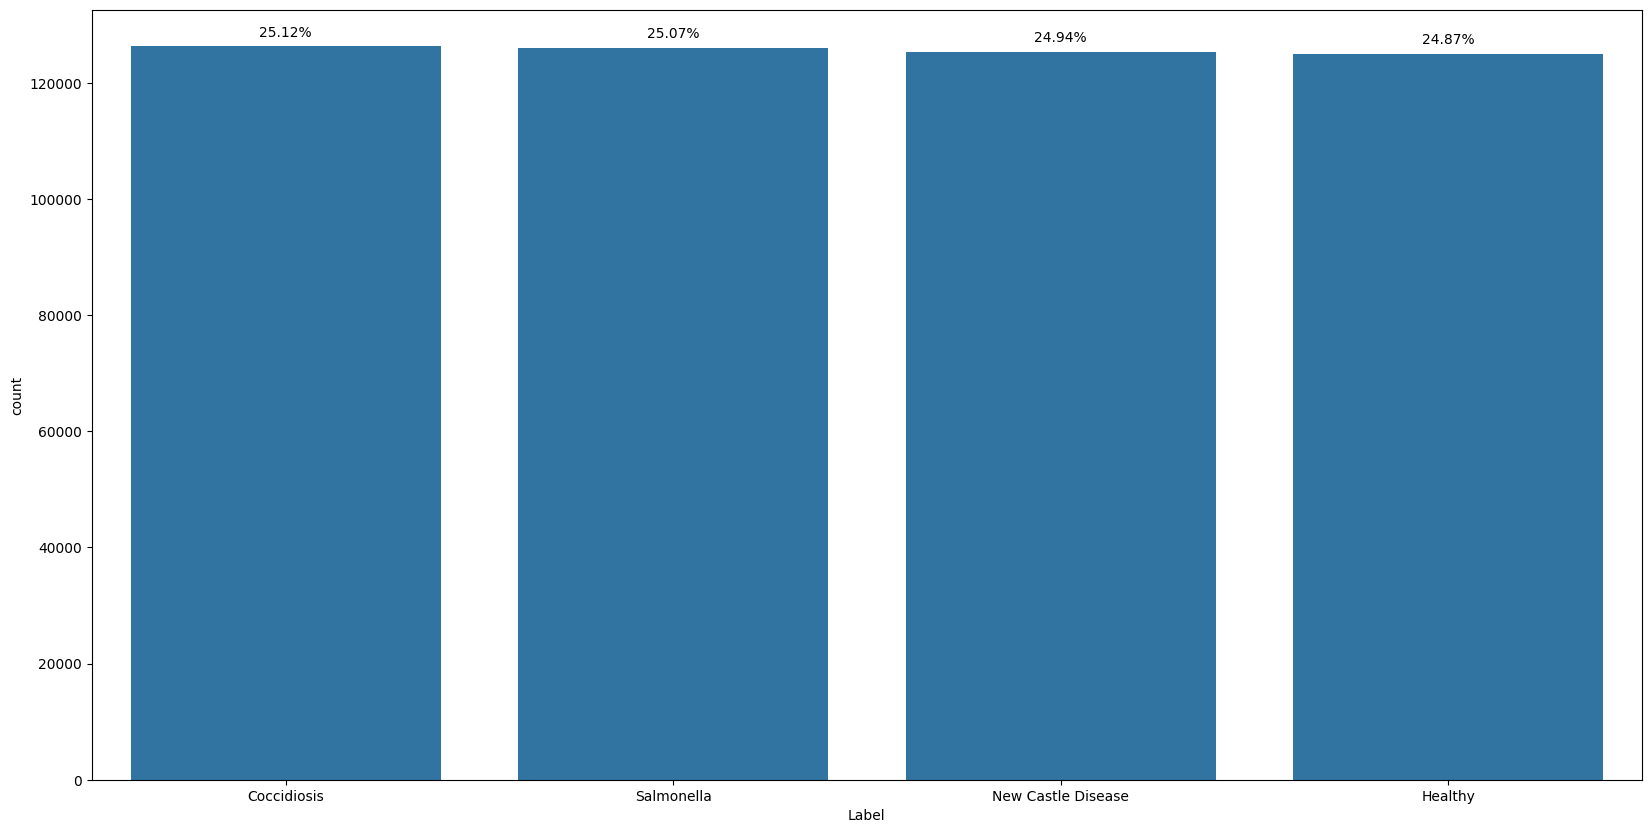

In [21]:
# menghitung banyak data tiap label
count_data = df["Label"].value_counts()
percentage_data = df["Label"].value_counts(normalize=True) * 100  # Calculate percentage
print(percentage_data)

# mengurutkan kemunculan data label dari paling banyak
sorted_data = count_data.sort_values(ascending=False).index

plt.figure(figsize=(20, 10))
ax = sns.countplot(x=df["Label"], order=sorted_data)

for p in ax.patches:
    height = p.get_height()
    percentage = f'{(height / count_data.sum()) * 100:.2f}%'
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.xticks(rotation=0)
plt.show()

In [22]:
count_data = df["Label"].value_counts()
count_data

,count
Label,
Coccidiosis,126276
Salmonella,126000
New Castle Disease,125326
Healthy,125008


### Data Preprocessing

#### Split Dataset

In [27]:
# Split awal: train dan sisanya
df_train, df_temp = train_test_split(df, test_size=0.3, stratify=df['Label'], random_state=42)

# Split sisa menjadi val dan test (50% dari 30% = 15% total)
df_val, df_test = train_test_split(df_temp, test_size=0.5, stratify=df_temp['Label'], random_state=42)

# Tampilkan jumlah data per bagian
print(f"Train: {len(df_train)}")
print(f"Validation: {len(df_val)}")
print(f"Test: {len(df_test)}")

Train: 351827
Validation: 75391
Test: 75392


In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
val_test_datagen = ImageDataGenerator(rescale=1./255)

In [31]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col='Image',
    y_col='Label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # atau 'binary' jika hanya 2 kelas
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_val,
    x_col='Image',
    y_col='Label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col='Image',
    y_col='Label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 351827 validated image filenames belonging to 4 classes.
Found 75391 validated image filenames belonging to 4 classes.
Found 75392 validated image filenames belonging to 4 classes.


In [35]:
import numpy as np
from collections import Counter

# Ambil list kelas dari mapping class_indices (urutannya sesuai index)
class_names = list(train_generator.class_indices.keys())

# classes adalah array angka label per sampel
class_labels_int = train_generator.classes

# Hitung jumlah tiap label
counts = Counter(class_labels_int)

# Tampilkan label dan jumlahnya
for i, class_name in enumerate(class_names):
    print(f"{class_name}: {counts[i]}")

Coccidiosis: 88393
Healthy: 87506
New Castle Disease: 87728
Salmonella: 88200


label dataset train hampir sama jadi tidak perlu penanganan unbalanced data

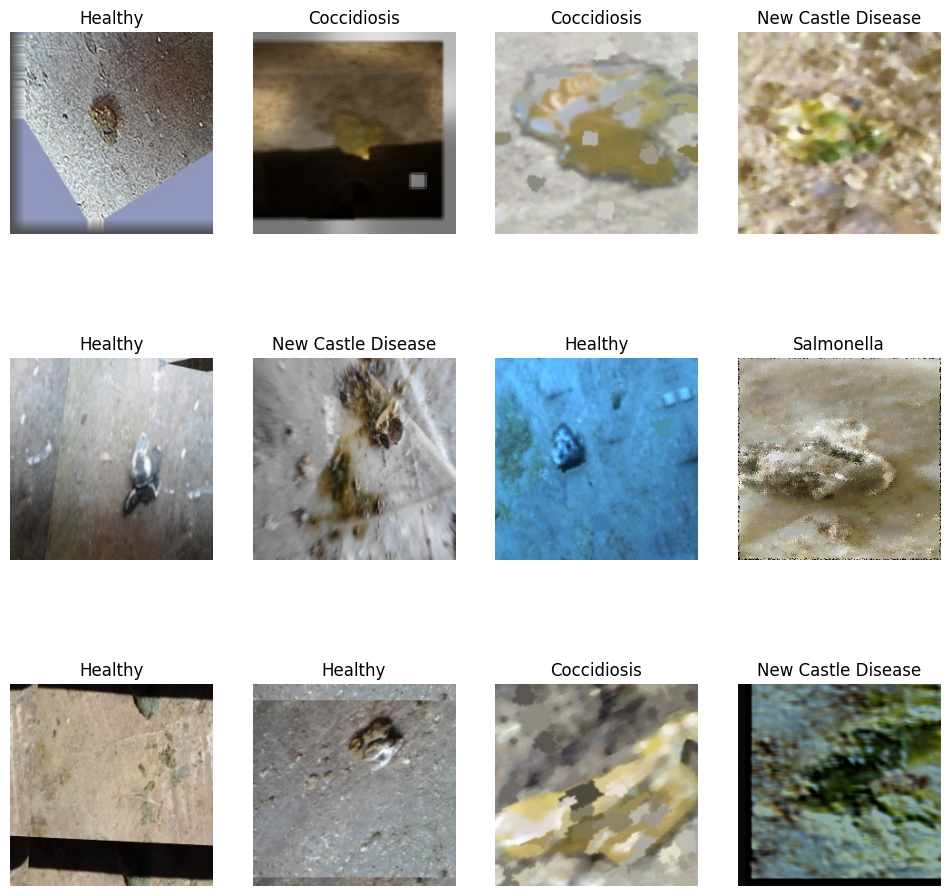

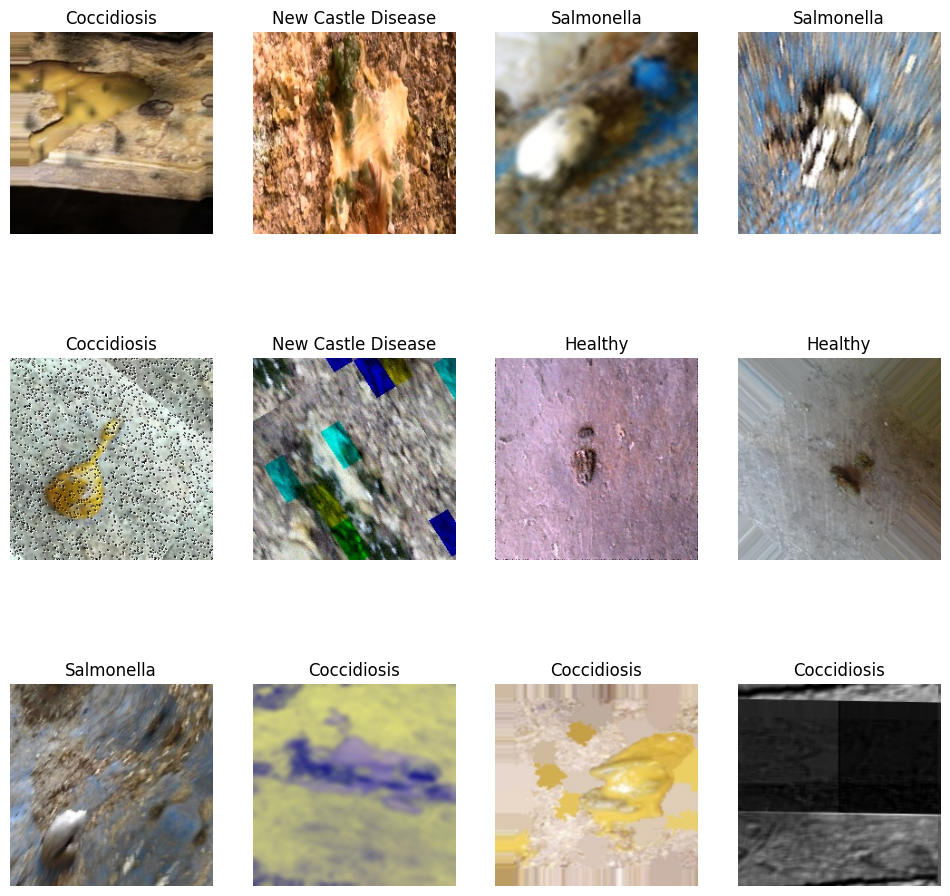

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Ambil batch pertama
images, labels = next(train_generator)

# Dapatkan mapping index ke nama label
index_to_label = {v: k for k, v in train_generator.class_indices.items()}

plt.figure(figsize=(12, 12))
for i in range(12):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])
    label_idx = np.argmax(labels[i])  # dapatkan index label
    label_name = index_to_label[label_idx]  # map ke nama label
    plt.title(label_name)
    plt.axis("off")
plt.show()

## Modelling

In [49]:
from tensorflow.keras.applications import MobileNetV2
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

In [50]:
from tensorflow.keras.layers import GlobalAveragePooling2D
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
predictions = Dense(len(class_names), activation="softmax")(x)

# ini menggabungkan ke model akhir
model = Model(inputs=base_model.input, outputs=predictions)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 2,025,924 (7.73 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [51]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [52]:
from tensorflow.keras.callbacks import EarlyStopping

# Callback: berhenti jika val_accuracy >= 0.98
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    verbose=1,
    mode='max',
    restore_best_weights=True
)
EPOCHS = 30
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator),
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/30
10995/10995 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8180 - loss: 0.4670

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


10995/10995 ━━━━━━━━━━━━━━━━━━━━ 1284s 113ms/step - accuracy: 0.8180 - loss: 0.4670 - val_accuracy: 0.9062 - val_loss: 0.2482
Epoch 2/30
10995/10995 ━━━━━━━━━━━━━━━━━━━━ 1251s 111ms/step - accuracy: 0.9127 - loss: 0.2323 - val_accuracy: 0.9118 - val_loss: 0.2441
Epoch 3/30
10995/10995 ━━━━━━━━━━━━━━━━━━━━ 1209s 110ms/step - accuracy: 0.9332 - loss: 0.1765 - val_accuracy: 0.9256 - val_loss: 0.2035
Epoch 4/30
10995/10995 ━━━━━━━━━━━━━━━━━━━━ 1242s 111ms/step - accuracy: 0.9469 - loss: 0.1417 - val_accuracy: 0.9219 - val_loss: 0.2213
Epoch 5/30
10995/10995 ━━━━━━━━━━━━━━━━━━━━ 1247s 113ms/step - accuracy: 0.9560 - loss: 0.1170 - val_accuracy: 0.9301 - val_loss: 0.2140
Epoch 6/30
10995/10995 ━━━━━━━━━━━━━━━━━━━━ 1315s 120ms/step - accuracy: 0.9634 - loss: 0.0982 - val_accuracy: 0.9306 - val_loss: 0.2200
Epoch 7/30
10995/10995 ━━━━━━━━━━━━━━━━━━━━ 1264s 113ms/step - accuracy: 0.9678 - loss: 0.0859 - val_accuracy: 0.9274 - val_loss: 0.2492
Epoch 8/30
10995/10995 ━━━━━━━━━━━━━━━━━━━━ 1225s 11

In [54]:
test_lost  , test_acc = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

2356/2356 ━━━━━━━━━━━━━━━━━━━━ 225s 95ms/step - accuracy: 0.9280 - loss: 0.2240

Test Accuracy: 92.77%


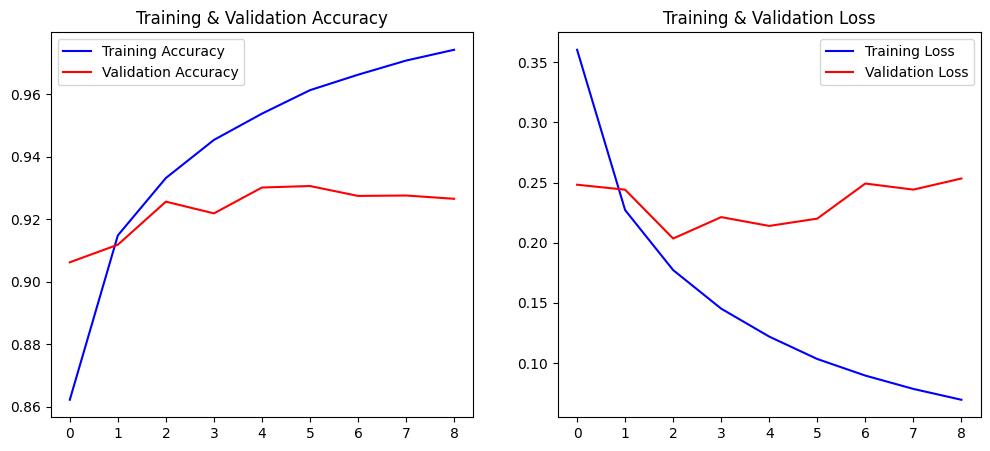

In [55]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, "b", label="Training Accuracy")
plt.plot(epochs, val_acc, "r", label="Validation Accuracy")
plt.legend()
plt.title("Training & Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, "b", label="Training Loss")
plt.plot(epochs, val_loss, "r", label="Validation Loss")
plt.legend()
plt.title("Training & Validation Loss")

plt.show()

In [56]:
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

2356/2356 ━━━━━━━━━━━━━━━━━━━━ 221s 94ms/step - accuracy: 0.9280 - loss: 0.2240

Test Accuracy: 92.77%


In [57]:
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

for i in range(10):
    print(f"Image {i+1}: True Label = {class_labels[true_classes[i]]}, Predicted = {class_labels[predicted_classes[i]]}")

2356/2356 ━━━━━━━━━━━━━━━━━━━━ 164s 68ms/step
Image 1: True Label = Coccidiosis, Predicted = Coccidiosis
Image 2: True Label = Coccidiosis, Predicted = Coccidiosis
Image 3: True Label = New Castle Disease, Predicted = New Castle Disease
Image 4: True Label = New Castle Disease, Predicted = New Castle Disease
Image 5: True Label = Salmonella, Predicted = Salmonella
Image 6: True Label = Coccidiosis, Predicted = Coccidiosis
Image 7: True Label = New Castle Disease, Predicted = Salmonella
Image 8: True Label = Salmonella, Predicted = Salmonella
Image 9: True Label = Coccidiosis, Predicted = Coccidiosis
Image 10: True Label = Salmonella, Predicted = Salmonella


In [58]:
from tensorflow.keras.preprocessing import image

img_path = "/content/ncd.152.jpg"
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
class_labels = list(test_generator.class_indices.keys())

print(f"\nPrediksi: {class_labels[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

Prediksi: New Castle Disease


In [ ]:
num_samples = 6
sample_indices = random.sample(range(len(test_generator.filenames)), num_samples)

plt.figure(figsize=(12, 6))
for i, idx in enumerate(sample_indices):
    img_path = os.path.join(test_dir, test_generator.filenames[idx])

    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction)
    true_class = test_generator.classes[idx]

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img)
    plt.title(f"True: {class_labels[true_class]}\nPred: {class_labels[predicted_class]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


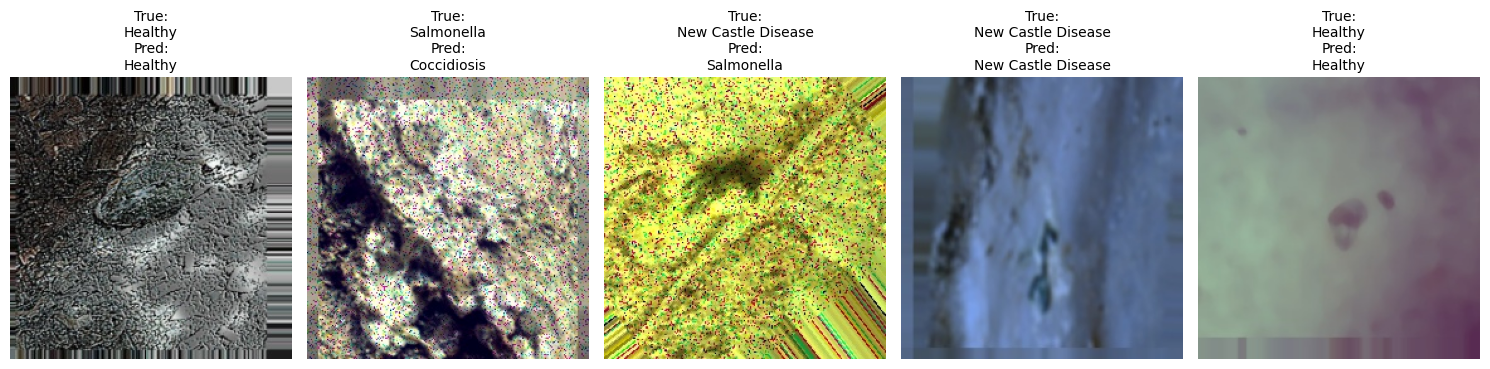

In [62]:
# Ambil satu batch dari generator (pastikan batch_size >= 5)
images, labels = next(test_generator)

# Prediksi model
predictions = model.predict(images)
predicted_indices = np.argmax(predictions, axis=1)
true_indices = np.argmax(labels, axis=1)

# Konversi index ke nama kelas
class_labels = list(test_generator.class_indices.keys())

# Tampilkan 5 gambar dan label
plt.figure(figsize=(15, 6))  # lebih tinggi supaya teks muat
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i])
    plt.title(f"True:\n{class_labels[true_indices[i]]}\nPred:\n{class_labels[predicted_indices[i]]}",
              fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Deployment

In [53]:
model.save("chicken_disease_model_500kpart1.h5")
print("Model berhasil disimpan sebagai chicken_disease_model.h5")

Model berhasil disimpan sebagai chicken_disease_model.h5


2356/2356 ━━━━━━━━━━━━━━━━━━━━ 119s 49ms/step


<Figure size 1000x800 with 0 Axes>

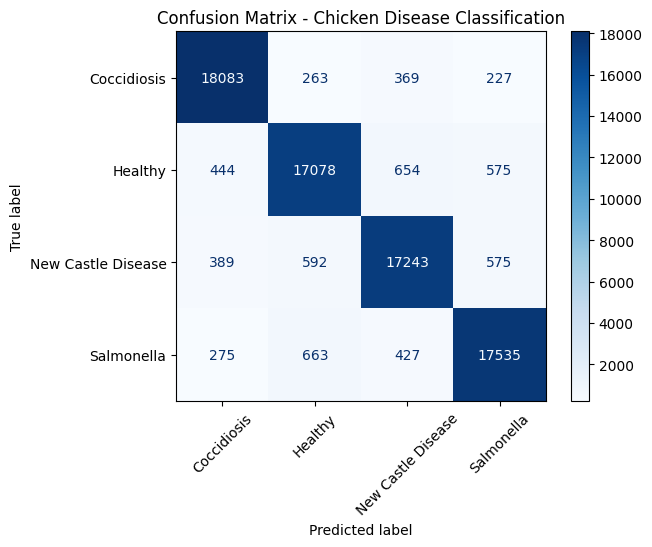

In [64]:
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Load model
model = load_model("chicken_disease_model_500kpart1.h5")

# Ambil data test (pastikan test_generator sudah dibuat seperti sebelumnya)
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

plt.figure(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix - Chicken Disease Classification")
plt.show()